In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Create a dedicated folder for this project in Drive
project_folder = '/content/drive/MyDrive/PlantDiseaseProject'
os.makedirs(project_folder, exist_ok=True)

print("✅ Project folder created!")
print("📁 Location:", project_folder)

✅ Project folder created!
📁 Location: /content/drive/MyDrive/PlantDiseaseProject


In [ ]:
# Check Drive is accessible
print("Drive contents:", os.listdir('/content/drive/MyDrive/'))
print("✅ Google Drive connected successfully!")

Drive contents: ['Colab Notebooks', 'Classroom', 'IMG_20250509_164757.jpg', 'IMG_20250522_235243.jpg', 'shweta_singh.pdf', 'IMG-20250919-WA0000.jpg', 'shweta singh resume - Shweta Singh.pdf', 'Shweta_Resume_With_Photo (2).pdf', 'Shweta_Resume_WP.pdf', 'PlantDiseaseProject']
✅ Google Drive connected successfully!


In [ ]:
import os
import json
import random
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from zipfile import ZipFile
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

random.seed(0)
np.random.seed(0)
tf.random.set_seed(0)

print("✅ All imports done!")

✅ All imports done!


In [ ]:
import json
import os

os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_credentials = {
    "username": "shwetaaaaaaaa",
    "key": "KGAT_2c6ea347e99d41e1d89ccd2a185c1a9f"
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✅ Kaggle setup done!")

✅ Kaggle setup done!


In [ ]:
!pip install kaggle -q
!kaggle datasets download -d abdallahalidev/plantvillage-dataset
print("✅ Download done!")

with ZipFile('/content/plantvillage-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')
print("✅ Unzip done!")

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:16<00:00, 135MB/s]

✅ Download done!
✅ Unzip done!


In [ ]:
base_path = "/content/plantvillage dataset"
base_dir = f"{base_path}/color"
img_size = 224
batch_size = 32

print("✅ Folders found:", os.listdir(base_path))
print("✅ Total classes:", len(os.listdir(base_dir)))

✅ Folders found: ['segmented', 'color', 'grayscale']
✅ Total classes: 38


In [ ]:
data_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='training',
    class_mode='categorical'
)

validation_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical'
)

print("✅ Generators created!")

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
✅ Generators created!


In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu',
          input_shape=(img_size, img_size, 3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(train_generator.num_classes, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model built and compiled!")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Model built and compiled!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    47,776,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,805,158 (182.36 MB)

 Trainable params: 47,805,158 (182.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=5,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size
)
print("✅ Training done!")

Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 110s 76ms/step - accuracy: 0.7451 - loss: 0.9118 - val_accuracy: 0.8657 - val_loss: 0.4382
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 99s 73ms/step - accuracy: 0.9212 - loss: 0.2508 - val_accuracy: 0.8610 - val_loss: 0.4511
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 97s 72ms/step - accuracy: 0.9631 - loss: 0.1155 - val_accuracy: 0.8922 - val_loss: 0.3977
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 142s 104ms/step - accuracy: 0.9738 - loss: 0.0817 - val_accuracy: 0.8879 - val_loss: 0.4730
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 89s 66ms/step - accuracy: 0.9812 - loss: 0.0585 - val_accuracy: 0.8709 - val_loss: 0.5952
✅ Training done!


In [ ]:
project_folder = '/content/drive/MyDrive/PlantDiseaseProject'

# 1. Save model to Drive
model.save(f'{project_folder}/plant_disease_model.keras')
print("✅ Model saved to Drive!")

# 2. Save class indices to Drive
class_indices = {v: k for k, v in train_generator.class_indices.items()}
json.dump(class_indices,
    open(f'{project_folder}/class_indices.json', 'w'))
print("✅ Class indices saved to Drive!")

# 3. Save history to Drive
import pickle
with open(f'{project_folder}/training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)
print("✅ History saved to Drive!")

# 4. Also save locally
model.save('plant_disease_model.keras')
json.dump(class_indices, open('class_indices.json', 'w'))
print("✅ Also saved locally!")

print("\n🎉 EVERYTHING SAVED! YOU ARE SAFE NOW!")

✅ Model saved to Drive!
✅ Class indices saved to Drive!
✅ History saved to Drive!
✅ Also saved locally!

🎉 EVERYTHING SAVED! YOU ARE SAFE NOW!


In [ ]:
project_folder = '/content/drive/MyDrive/PlantDiseaseProject'

print("📁 Files in Google Drive:")
print(os.listdir(project_folder))

print("\n📁 Local files:")
print("Model:", os.path.exists('plant_disease_model.keras'))
print("Class indices:", os.path.exists('class_indices.json'))

📁 Files in Google Drive:
['plant_disease_model.keras', 'class_indices.json', 'training_history.pkl']

📁 Local files:
Model: True
Class indices: True


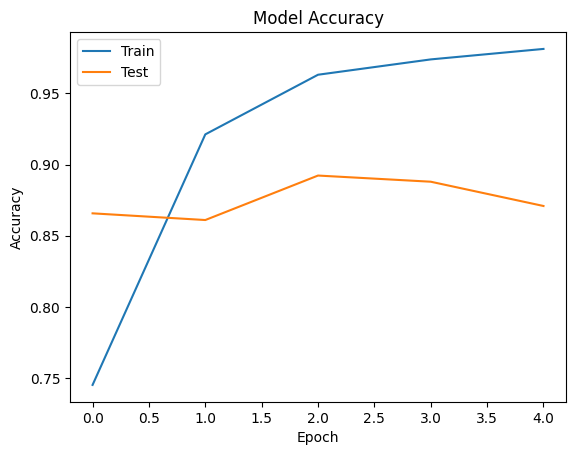

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [ ]:
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    img = Image.open(image_path)
    img = img.resize(target_size)
    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array.astype('float32') / 255.
    return img_array

def predict_image_class(model, image_path, class_indices):
    preprocessed_img = load_and_preprocess_image(image_path)
    predictions = model.predict(preprocessed_img)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = class_indices[predicted_class_index]
    return predicted_class_name

# Test on real image
test_files = os.listdir(f"{base_path}/color/Apple___Black_rot")
image_path = f"{base_path}/color/Apple___Black_rot/{test_files[0]}"

predicted = predict_image_class(model, image_path, class_indices)
print("✅ Predicted Class:", predicted)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 944ms/step
✅ Predicted Class: Apple___Black_rot


In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/PlantDiseaseProject/plant_disease_model.keras')
files.download('/content/drive/MyDrive/PlantDiseaseProject/class_indices.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>